In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY") 

c:\Users\sumsaras\Documents\PersonalWorkspace\AI_Learning\RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


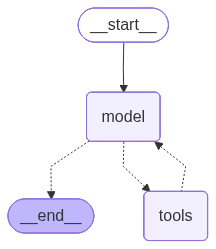

In [2]:
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
llm = init_chat_model(model='openai/gpt-oss-120b',temperature=0.4, model_provider='groq')

def get_weather(city:str):
    """Get the weather details"""
    return f"Today is sunny in {city}"

def get_order(order:str):
    """Get status of your order"""
    return f"Your {order} is in transit"

agent = create_agent(
    model=llm,
    tools=[get_weather,get_order],
    system_prompt="You are a helpful assistant"
)
agent

In [3]:
agent.invoke({"messages":"What is the weather in delhi?"})

{'messages': [HumanMessage(content='What is the weather in delhi?', additional_kwargs={}, response_metadata={}, id='a3404a6d-4664-4394-bf27-44bb9a745210'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is the weather in delhi?" We need to call the get_weather function with city "Delhi". Use correct capitalization? Probably "Delhi". Let\'s call.', 'tool_calls': [{'id': 'fc_81b751d2-89b3-4efb-8129-f4fcf46ff2b4', 'function': {'arguments': '{"city":"Delhi"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 156, 'total_tokens': 221, 'completion_time': 0.135178924, 'completion_tokens_details': {'reasoning_tokens': 38}, 'prompt_time': 0.005852026, 'prompt_tokens_details': None, 'queue_time': 0.058348494, 'total_time': 0.14103095}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_45f51928b5', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': No

In [ ]:
agent.invoke({"messages":"Where is my margheritta pizza with order number 123kudos343"})

{'messages': [AIMessage(content="Sure, I'm here to help! Let me know what you need assistance with.", additional_kwargs={'reasoning_content': 'The user hasn\'t asked anything yet. The system says we are ChatGPT. The developer says "You are a helpful assistant". No user query. Probably need to wait for user.'}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 144, 'total_tokens': 206, 'completion_time': 0.135374725, 'completion_tokens_details': {'reasoning_tokens': 37}, 'prompt_time': 0.00623576, 'prompt_tokens_details': None, 'queue_time': 0.05846931, 'total_time': 0.141610485}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_45f51928b5', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e867a-ef07-7872-9e50-5006f3b05ee2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 144, 'output_tokens': 62, 'total_tokens': 206, 'output_token_details': {'reasoning': 37}

In [5]:
response = llm.stream("Write a 50 words paragraph on AI")
# print(response)
for chunk in response:
    print(chunk, end="|", flush=True)

content='' additional_kwargs={} response_metadata={'model_provider': 'groq'} id='lc_run--019e8676-bc37-77d0-88d0-3063dceaa902' tool_calls=[] invalid_tool_calls=[] tool_call_chunks=[]|content='' additional_kwargs={'reasoning_content': 'The'} response_metadata={'model_provider': 'groq'} id='lc_run--019e8676-bc37-77d0-88d0-3063dceaa902' tool_calls=[] invalid_tool_calls=[] tool_call_chunks=[]|content='' additional_kwargs={'reasoning_content': ' user'} response_metadata={'model_provider': 'groq'} id='lc_run--019e8676-bc37-77d0-88d0-3063dceaa902' tool_calls=[] invalid_tool_calls=[] tool_call_chunks=[]|content='' additional_kwargs={'reasoning_content': ' asks'} response_metadata={'model_provider': 'groq'} id='lc_run--019e8676-bc37-77d0-88d0-3063dceaa902' tool_calls=[] invalid_tool_calls=[] tool_call_chunks=[]|content='' additional_kwargs={'reasoning_content': ':'} response_metadata={'model_provider': 'groq'} id='lc_run--019e8676-bc37-77d0-88d0-3063dceaa902' tool_calls=[] invalid_tool_calls=[]

### Langchain tools
This gives you insight how the agent calls the tool internally.

In [6]:
from langchain.tools import tool

@tool
def get_weather_details(city: str) -> str:
    """Get weather details by providing city"""
    return f"Today is cloudy in {city}"

In [7]:
model_with_tools = llm.bind_tools([get_weather_details])
response = model_with_tools.invoke("What is the weather in Chattisgarh?")
tool = response.tool_calls
tool

[{'name': 'get_weather_details',
  'args': {'city': 'Chhattisgarh'},
  'id': 'fc_16384591-70e0-45cc-a595-2e9554e3ccd0',
  'type': 'tool_call'}]

In [9]:
messages = [{"role": "user", "content":"What is the weather in Delhi?"}]
ai_msg = model_with_tools.invoke(messages)
messages.append(ai_msg)

for tool_call in ai_msg.tool_calls:
    tool_msg = get_weather_details.invoke(tool_call)
    messages.append(tool_msg)

final_response = model_with_tools.invoke(messages)
print(final_response)
print(messages)
print(final_response.content)

content='The weather in Delhi today is cloudy.' additional_kwargs={'reasoning_content': 'The user asked: "What is the weather in Delhi?" The function returned "Today is cloudy in Delhi". We should respond with that info.'} response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 160, 'total_tokens': 207, 'completion_time': 0.102836977, 'completion_tokens_details': {'reasoning_tokens': 30}, 'prompt_time': 0.006070493, 'prompt_tokens_details': None, 'queue_time': 0.064858057, 'total_time': 0.10890747}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_a09bde29de', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019e8677-22a5-70c3-b753-74b4d9577c3d-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 160, 'output_tokens': 47, 'total_tokens': 207, 'output_token_details': {'reasoning': 30}}
[{'role': 'user', 'content': 'What is the weather in Delhi?'}, AIMessage(content='', addit